In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [50]:
ny = 1024

path = "../../outputs/dustydisk_alpha/"

In [80]:
rmin = loadtxt(path+"/domain_y.dat")[3:-3]
rmed = 0.5*(rmin[1:]+rmin[:-1])

n = 15

dustvr0 = fromfile(path+"/dustvy0.dat")
dustvr = fromfile(path+"/dustvy{:d}.dat".format(n))

gasvr0 = fromfile(path+"/gasvy0.dat")
gasvr = fromfile(path+"/gasvy{:d}.dat".format(n))

cs = fromfile(path+"/gasenergy0.dat")
dens = fromfile(path+"/gasdens{:d}.dat".format(n))

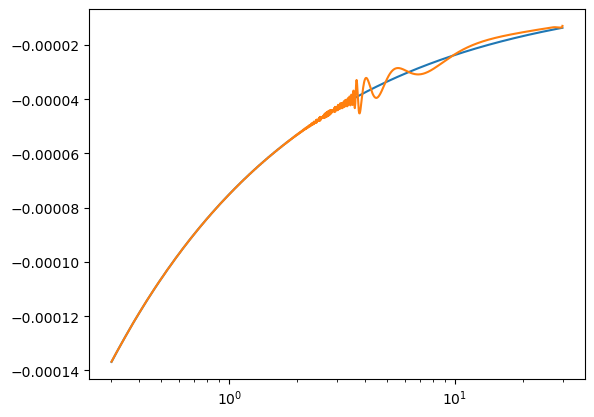

In [81]:
plot(rmed, dustvr0)
plot(rmed, dustvr)

xscale('log')
show()

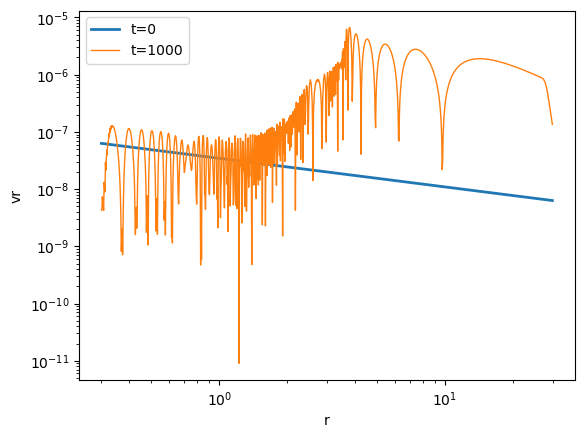

In [82]:
plot(rmed, abs(gasvr0), '-',lw=2, label='t=0')
plot(rmed, abs(gasvr), '-', lw=1, label='t=1000')

yscale('log')
legend()
xscale('log')
xlabel('r')
ylabel('vr')
show()

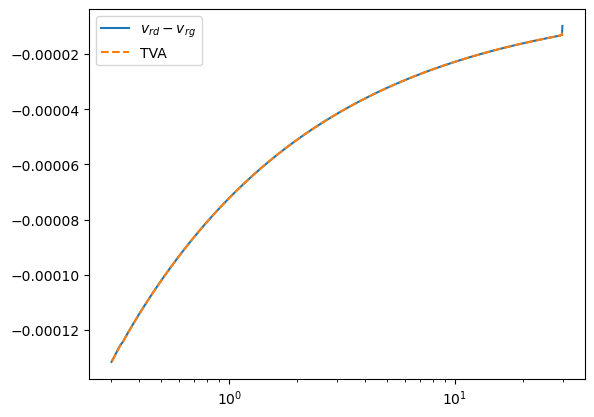

In [227]:
rhomed  = (dens[1:]+dens[:-1])*0.5
omega   = sqrt(1/rmed**3)
omegamed= (omega[1:]+omega[:-1])*0.5
P = cs**2*dens
gradP = 1/(rhomed*omegamed) * ( P[1:]-P[:-1] )/(rmed[1:]-rmed[:-1])

Ts = 0.02
eps = 0.04

plot( rmed, dustvr-gasvr , label=r"$v_{rd}-v_{rg}$")

### TVA (aproxi...)
plot(rmed[1:],  gradP*Ts*(1+eps)/((1+eps)**2+Ts**2), '--', label='TVA')
xscale('log')
legend()
show()
